In [1]:
from numpy import sqrt, linspace
from scipy.optimize import fsolve
from scipy.special import jv, kv
import matplotlib.pyplot as plt

In [2]:
V = 8
l = 0

In [3]:
def eigen_eq_for_LP_lm(V, l):
    def func_to_cal(u):
        w = sqrt(V*V - u*u)
        return jv(l - 1, u) / jv(l, u) + (w / u) * kv(l - 1, w) / kv(l, w)
    return func_to_cal

In [4]:
def eq_left_side(V, l):
    def lhs(u):
        w = sqrt(V*V - u*u)
        return jv(l - 1, u) / jv(l, u)
    return lhs

In [5]:
def eq_right_side(V, I):
    def rhs(u):
        w = sqrt(V*V - u*u)
        return -(w / u) * kv(l - 1, w) / kv(l, w)
    return rhs

In [6]:
root = fsolve(eigen_eq_for_LP_lm(V,l), [2.1, 5.2, 7.0])
print(root)

[2.13458308 4.86579678 7.45285662]


C:\Users\jkkow\AppData\Local\Temp\ipykernel_25652\3648538631.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = sqrt(V*V - u*u)
C:\Users\jkkow\AppData\Local\Temp\ipykernel_25652\129632344.py:4: RuntimeWarning: invalid value encountered in multiply
  return -(w / u) * kv(l - 1, w) / kv(l, w)


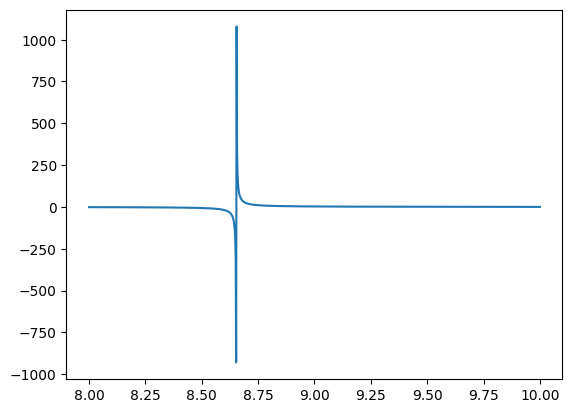

In [12]:
u = linspace(10, V, 1000)
lhs = eq_left_side(V, l)
rhs = eq_right_side(V, l)
plt.plot(u, lhs(u), rhs(u))